Task:
Simulate 1000 random current in the range (0.01, 1.5) in scenario A, 
given 
- current $I_1$ at position 1 of `qrodrupole focusing Lattice`(beamline 0.35878m - 0.44768m) and $I_3$ at position 3 of `qrodrupole defocusing Lattice`(beamline 0.64453m - 0.73342m),
- objective that $\alpha_x=0$ at position 8, and $\alpha_y=0$ at position 9
- weight for each objective(both 1 for `$\alpha_x=0$ at position 8` and `$\alpha_y=0$ at position 9`)

return 
- weighted MSE function $\phi(k)$
- Jacobian matrix $J(k) \in \mathbb{R}^{2 \times 2}$
- Hessian matrix $H(k) \in \mathbb{R}^{2 \times 2}$
- Eigenvalues/Eigenvectors of Hessian matrix $H(k)$

In [1]:
import numpy as np
import torch
import copy
import time
import pickle
import os, sys
current_dir=os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(current_dir, "../")))
sys.path.insert(0, os.path.abspath(os.path.join(current_dir, "../../backend")))
# print(sys.path)

# Initialize the beamline
from configs import *
from experiments_utils import load_results, save_results
from ebeam import beam as ebeam_class
from beamline import lattice
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer

c:\Users\yilu2\my_files\research\FELsim\backend


In [65]:
import time
def time_computation(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        # print(f"Time elasted: {end_time - start_time:.4f} seconds")
        dt = end_time - start_time
        if isinstance(result, tuple):
            return (*result, dt)
        else:
            return result, dt
    return wrapper

compute the weighted MSE function $\phi(k)$ for scenario A, evalutated at position 8 for $\alpha_x$ and position 9 for $\alpha_y$

In [91]:
# available current controllable

FELSIM_S1_CURRENTS = {
     1: 0.8218,  3: 1.0430,
    10: 3.8834,
    16: 2.2396, 18: 4.9532, 20: 3.4258,
    27: 4.6657,
    33: 2.6942, 35: 2.6523, 37: 0.2768, 39: 0.2768, 41: 2.6523, 43: 2.6942,
    50: 4.6739,
    56: 3.1219, 58: 3.3129,
    61: 5.1775, 63: 4.0434,
    70: 4.6818,
    76: 3.9336, 78: 4.0787, 80: 0.0139,
    87: 1.3624, 93: 0.9452, 95: 2.8851, 97: 2.1921,
}
tunable_current=list(FELSIM_S1_CURRENTS.keys())

In [ ]:
@time_computation
def compute_weighted_MSE(I_dict, A_VARS, A_OBJ):
    """
    I_list: list of currents at different positions
    weight: weight for the objectives
    eval_pos: positions to evaluate the objectives
    targets: list of target values for the objectives
    A_OBJ: the object to be optimized
    """
    bl = ExcelElements(EXCEL_PATH).create_beamline()
    p = PARTICLES.clone()
    obj_copy = copy.deepcopy(A_OBJ)
    opti = beamOptimizer(bl, p, noise=False)
    weight=[i[0]["weight"] for i in list(A_OBJ.values())]
    eval_pos=list(A_OBJ.keys())
    SP = {var_name: {"bounds": CURRENT_BOUNDS, "start": 0.5} for var_name in I_dict.keys()}
    opti._prepare(A_VARS, SP, obj_copy)

    I_list = [I_dict[var_name] for var_name in opti.variablesToOptimize]
    phi=opti._optiSpeed(I_list)
    num_goals = 2
    r_list = []
    # print(opti.objectives)
    for i in range(len(opti.objectives)):
        stat = float(opti.objectives[eval_pos[i]][0]["measured"])
        goal=float(opti.objectives[eval_pos[i]][0]["goal"])
        r = np.sqrt(weight[i] / num_goals) * (stat -goal) / weight[i]
        r_list.append(r)
        
    # stat_y = float(opti.objectives[eval_pos[1]][0]["measured"])
    # r_y = np.sqrt(weight[1] / num_goals) * (stat_y - targets[1]) / weight[1]
    # r_list.append(r_y)
    
    r = np.array(r_list)
    return r, phi

I_dict_test = {"I": 0.7469, "I2": 0.5819, "I3": 0.4}

A_VARS_test = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
    10: ["I3", "current", lambda x: x],
}
A_OBJ_test = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
    12: [{"measure": ["x", "beta"], "goal": 0.0, "weight": 1.0}],
}

r, phi, time_elasted = compute_weighted_MSE(I_dict_test, A_VARS_test, A_OBJ_test)
# r, phi = res
print(f"R vector: {r}")
print(f"Phi value: {phi}")
print(f"Time taken: {time_elasted:.4f} seconds")
# print(compute_weighted_MSE(I_dict_test, A_VARS_test, A_OBJ_test))

[-0.02801081  0.01656791  0.61018631]
R vector: [-0.02801081  0.01656791  0.61018631]
Phi value: 0.24892428980866832
Time taken: 4.3456 seconds


compute Jacobian matrix $J(k)$ for scenario A, with dimension $2 \times 2$, evaluated at position 8 for $\alpha_x$ and position 9 for $\alpha_y$

In [ ]:
from copy import deepcopy

def perturb_currents(I_dict, delta=1e-5):
    """
    Perturb the currents in I_dict by delta, suppose variable number is k
    Returns k number of dictionary set, where each set is a tuple with two dictionaries, one with the current perturbed by +delta and the other by -delta.
    """
    I_dict_plus_dict = {}
    I_dict_minus_dict = {}
    for i in range(len(I_dict)):
        I_dict_plus = deepcopy(I_dict)
        I_dict_minus = deepcopy(I_dict)
        I_dict_plus[list(I_dict.keys())[i]] += delta
        I_dict_minus[list(I_dict.keys())[i]] -= delta
        I_dict_plus_dict[i] = I_dict_plus
        I_dict_minus_dict[i] = I_dict_minus
    return I_dict_plus_dict, I_dict_minus_dict

print(f"Original currents: {I_dict_test}")
print(f"Perturbed currents (plus delta): {perturb_currents(I_dict_test, delta=1e-5)[0]}")
print(f"Perturbed currents (minus delta): {perturb_currents(I_dict_test, delta=1e-5)[1]}")


Original currents: {'I_1': 0.7469, 'I_3': 0.5819}
Perturbed currents (plus delta): {0: {'I_1': 0.74691, 'I_3': 0.5819}, 1: {'I_1': 0.7469, 'I_3': 0.5819099999999999}}
Perturbed currents (minus delta): {0: {'I_1': 0.74689, 'I_3': 0.5819}, 1: {'I_1': 0.7469, 'I_3': 0.58189}}


In [ ]:
@time_computation
def compute_jacobian(I_dict, A_VARS, A_OBJ, delta=1e-5):
    """
    Compute the Jacobian matrix J(k) for scenario A, with dimension 2x2 
    I_1: current at position 1 for qrodrupole focusing Lattice 1
    I_3: current at position 3 for qrodrupole defocusing Lattice 1
    r: the R vector computed from compute_weighted_MSE
    delta: small perturbation for numerical differentiation
    """
    var_num = len(A_VARS)
    obj_num = len(A_OBJ)
    J = np.zeros((obj_num, var_num))
    I_dict_plus_dict, I_dict_minus_dict = perturb_currents(I_dict, delta)
    for i in range(var_num):
        I_dict_plus = I_dict_plus_dict[i]
        I_dict_minus = I_dict_minus_dict[i]
        r_plus_delta = compute_weighted_MSE(I_dict_plus, A_VARS, A_OBJ)[0]
        r_minus_delta = compute_weighted_MSE(I_dict_minus, A_VARS, A_OBJ)[0]
        J[:, i] = (r_plus_delta - r_minus_delta) / (2 * delta)
    
    
    # # Perturb I_1
    # r_plus_delta, _ = compute_weighted_MSE(I_1 + delta, I_3)
    # r_minus_delta, _ = compute_weighted_MSE(I_1 - delta, I_3)
    
    # J[:, 0] = (r_plus_delta - r_minus_delta) / (2 * delta)
    
    # # Perturb I_3
    # r_plus_delta, _ = compute_weighted_MSE(I_1, I_3 + delta)
    # r_minus_delta, _ = compute_weighted_MSE(I_1, I_3 - delta)
    
    # J[:, 1] = (r_plus_delta - r_minus_delta) / (2 * delta)
    
    return J


I_dict_test = {"I": 0.7469, "I2": 0.5819, "I3": 0.4, "I4": 0.5}
A_VARS_test = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
    tunable_current[2]: ["I3", "current", lambda x: x],
    tunable_current[3]: ["I4", "current", lambda x: x],
}
A_OBJ_test = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}
J, time_elasted = compute_jacobian(I_dict_test, A_VARS_test, A_OBJ_test)
print(f"Jacobian matrix J(k):\n{J}")
print(f"Time taken to compute Jacobian: {time_elasted:.4f} seconds")
# print(f"Jacobian matrix J(k):\n{compute_jacobian(I_dict_test, A_VARS_test, A_OBJ_test)}")

compute Hessian matrix based on $\phi$

In [ ]:
# def compute_grad_phi(I_dict, A_VARS, A_OBJ, delta=1e-5):
#     r=compute_weighted_MSE(I_dict, A_VARS, A_OBJ)[0]
#     return 2*compute_jacobian(I_dict, A_VARS, A_OBJ, delta).T @ r
# # print(I_dict_test, A_VARS_test, A_OBJ_test)
# # r=compute_weighted_MSE(I_dict_test, A_VARS_test, A_OBJ_test)[0]
# # print(r)
# print(f"Gradient of phi: {compute_grad_phi(I_dict_test, A_VARS_test, A_OBJ_test)}")

Gradient of phi: [0.03067298 0.30020508]


In [72]:
@time_computation
def compute_hessian_phi(I_dict, A_VARS, A_OBJ, delta=1e-5):
    var_num = len(I_dict)
    def compute_grad_phi(I_dict, A_VARS, A_OBJ, delta=1e-5):
        r=compute_weighted_MSE(I_dict, A_VARS, A_OBJ)[0]
        return 2*compute_jacobian(I_dict, A_VARS, A_OBJ, delta)[0].T @ r
    # print(f"Gradient of phi: {compute_grad_phi(I_dict_test, A_VARS_test, A_OBJ_test)}")
    H = np.zeros((var_num, var_num))
    I_dict_plus_dict, I_dict_minus_dict = perturb_currents(I_dict, delta)
    for i in range(var_num):
        I_dict_plus = I_dict_plus_dict[i]
        I_dict_minus = I_dict_minus_dict[i]
        grad_plus_delta = compute_grad_phi(I_dict_plus, A_VARS, A_OBJ, delta)
        grad_minus_delta = compute_grad_phi(I_dict_minus, A_VARS, A_OBJ, delta)
        
        # Perturb I_1 and I_3
        # if i == 0:
        #     grad_plus_delta = compute_grad_phi(I_dict_plus, A_VARS, A_OBJ, r, delta)
        #     grad_minus_delta = compute_grad_phi(I_dict_minus, A_VARS, A_OBJ, r, delta)
        # else:
        #     grad_plus_delta = compute_grad_phi(I_dict_plus, A_VARS, A_OBJ, r, delta)
        #     grad_minus_delta = compute_grad_phi(I_dict_minus, A_VARS, A_OBJ, r, delta)
        
        H[:, i] = (grad_plus_delta - grad_minus_delta) / (2 * delta)
    return H
# test

print(f"Hessian matrix H(k):\n{compute_hessian_phi(I_dict_test, A_VARS_test, A_OBJ_test)}")

Hessian matrix H(k):
(array([[ 150.20085701, -197.35681738],
       [-197.35681729,  316.38345146]]), 85.55668330192566)


In [74]:
@time_computation
def compute_eig(H):
    """
    Compute the eigenvalues and eigenvectors of the Hessian matrix H
    H: Hessian matrix
    """
    eigvals, eigvecs = np.linalg.eig(H)
    return eigvals, eigvecs
eigvals, eigvecs, time_elasted = compute_eig(np.array([[ 150.20085701, -197.35681738],
       [-197.35681729,  316.38345146]]))
print(f"Eigenvalues of Hessian matrix H(k):\n{eigvals}")
print(f"Eigenvectors of Hessian matrix H(k):\n{eigvecs}")
print(f"Time taken to compute eigenvalues and eigenvectors: {time_elasted:.4f} seconds")


Eigenvalues of Hessian matrix H(k):
[ 19.15697024 447.42733823]
Eigenvectors of Hessian matrix H(k):
[[-0.83307622  0.55315822]
 [-0.55315822 -0.83307622]]
Time taken to compute eigenvalues and eigenvectors: 0.0010 seconds


give a scan of current values in range (0.01, 1.5) for both $I_1$ and $I_3$, compute 
- phi
- Jacobian
- Hessian
- Eigenvalues/Eigenvectors of Hessian matrix 
Then speed up the computation by using multiprocessing.

In [102]:
# without multiprocessing, 2 variables, 2 objectives
def total_scan_execution(A_VARS_test, A_OBJ_test, sample_num):
    print(f"Scan current variables from position: {list(A_VARS_test.keys())}")

    print(f'Scan objectives from position: {["_".join(reversed(i[0]["measure"]))+"="+str(i[0]["goal"])+" @ position "+str(list(A_OBJ_test.keys())[j])+ " with weight "+str(i[0]["weight"]) for j, i in enumerate(list(A_OBJ_test.values()))]}')
    t0=time.time()    
    output_dict=list()
    time_log=dict()
    for i in range(sample_num):
        I_dict_test = {}
        for j in range(len(A_VARS_test)):
            if j==0:
                I_dict_test["I"] = np.random.uniform(0.01, 1.5) 
            else:
                I_dict_test["I"+str(j+1)] = np.random.uniform(0.01, 1.5)
        # I = np.random.uniform(0.01, 1.5)
        # I2 = np.random.uniform(0.01, 1.5)
        # I_dict_test = {"I": I, "I2": I2}
        # compute mse phi
        r, phi, time_mse = compute_weighted_MSE(I_dict_test, A_VARS_test, A_OBJ_test)
        # compute jacobian 
        J, time_jac = compute_jacobian(I_dict_test, A_VARS_test, A_OBJ_test)
        # compute hessian
        H, time_hess = compute_hessian_phi(I_dict_test, A_VARS_test, A_OBJ_test)
        # compute eigenvalues and eigenvectors
        eigvals, eigvecs, time_eig = compute_eig(H)
        output_dict.append({
            "current": tuple(I_dict_test.values()),
            "parameters": (phi, J, H, eigvals, eigvecs)
        })
        time_log["time_mse"] = time_log.get("time_mse", 0) + time_mse
        time_log["time_jac"] = time_log.get("time_jac", 0) + time_jac
        time_log["time_hess"] = time_log.get("time_hess", 0) + time_hess
        time_log["time_eig"] = time_log.get("time_eig", 0) + time_eig

    for i in time_log.keys():
        time_log[i]/=sample_num 

    t1=time.time()

    print(f"Total time taken without multiprocessing: {t1-t0:.4f} seconds")
    print(f"Time log: {time_log}")
    return output_dict, time_log, t1-t0

In [103]:
A_VARS_test = deepcopy(A_VARS)
A_OBJ_test = deepcopy(A_OBJ)
sample_num=2
total_scan_execution(A_VARS_test, A_OBJ_test, sample_num)

Scan current variables from position: [1, 3]
Scan objectives from position: ['alpha_x=0.0 @ position 8 with weight 1.0', 'alpha_y=0.0 @ position 9 with weight 1.0']
Total time taken without multiprocessing: 200.2950 seconds
Time log: {'time_mse': 3.7035375833511353, 'time_jac': 15.89497184753418, 'time_hess': 80.5484721660614, 'time_eig': 0.0004994869232177734}


([{'current': (0.2424677742592304, 0.24243183530094195),
   'parameters': (np.float64(0.01322617472400847),
    array([[ 6.09953239, -5.2208766 ],
           [-6.56598195,  8.26479279]]),
    array([[  42.2434238 , -175.36495257],
           [-175.36495634,   72.53574403]]),
    array([-118.62823739,  233.40740522]),
    array([[-0.73690196,  0.67599962],
           [-0.67599963, -0.73690197]]))},
  {'current': (0.09654458213061719, 1.3006024572046535),
   'parameters': (np.float64(781.7826536209436),
    array([[ 57.96378622, -34.91954289],
           [ 16.59286217, -28.66230212]]),
    array([[-44367.17875467,  -7886.70336956],
           [ -7886.70410332,   6061.55638529]]),
    array([-45571.82758917,   7266.2052198 ]),
    array([[-0.98853483,  0.15099303],
           [-0.15099304, -0.98853483]]))}],
 {'time_mse': 3.7035375833511353,
  'time_jac': 15.89497184753418,
  'time_hess': 80.5484721660614,
  'time_eig': 0.0004994869232177734},
 200.29496216773987)

change variable number n from 2 to 10, find the variation of time
test: 2,4,6,8,10
to save time, we can leave sample number=2, and it can be easily changed to a larger value

In [115]:
# toy example
print(tunable_current[10])
A_VARS_test = deepcopy(A_VARS)
A_OBJ_test = {
    40: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    42: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}


def prepare_A_VARS(num_current, tunable_current):
    A_VARS_test = {}
    for i in range(num_current):
        if i==0:
            A_VARS_test[tunable_current[i]] = ["I", "current", lambda x: x]
        else:
            A_VARS_test[tunable_current[i]] = ["I"+str(i+1), "current", lambda x: x]
    return A_VARS_test
sample_num=1
time_arr=[]
for j in range(2,11,2):
# for j in [4]:
    A_VARS_test = prepare_A_VARS(j, tunable_current)
    print(f"Number of variables: {j}, Current positions: {list(A_VARS_test.keys())}, {A_VARS_test}")
    A_OBJ_test = {
        40: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
        42: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
    }
    time_arr.append(total_scan_execution(A_VARS_test, A_OBJ_test, sample_num)[-1])

39
Number of variables: 2, Current positions: [1, 3], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17A5DEAC0>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E4D4860>]}
Scan current variables from position: [1, 3]
Scan objectives from position: ['alpha_x=0.0 @ position 40 with weight 1.0', 'alpha_y=0.0 @ position 42 with weight 1.0']
Total time taken without multiprocessing: 104.3894 seconds
Time log: {'time_mse': 4.073349237442017, 'time_jac': 14.672709226608276, 'time_hess': 85.64239001274109, 'time_eig': 0.0009984970092773438}
Number of variables: 4, Current positions: [1, 3, 10, 16], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E962020>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E94A160>], 10: ['I3', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E94A020>], 16: ['I4', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000

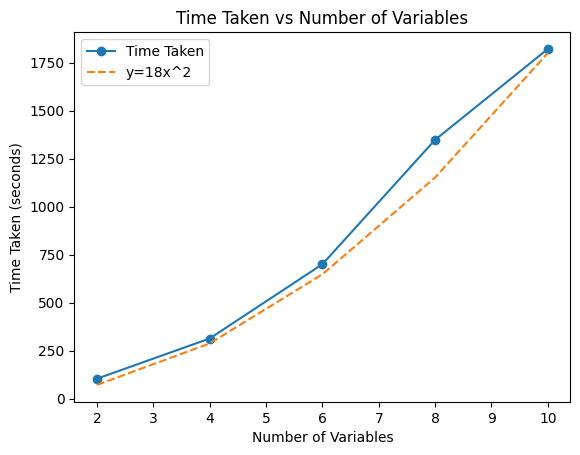

In [123]:
# plot the time curve
# attach y=x^2
import matplotlib.pyplot as plt

plt.plot(range(2,11,2), time_arr, marker='o')
plt.plot(range(2,11,2), [18*x**2 for x in range(2,11,2)], linestyle='--')
plt.xlabel('Number of Variables')
plt.ylabel('Time Taken (seconds)')
plt.legend(['Time Taken', 'y=18x^2'])
plt.title('Time Taken vs Number of Variables')
plt.show()

change number of objectives m from 2 to 10, find the variation of time
test: 2,4,6,8,10
to save time, we can leave sample number=2, and it can be easily changed to a larger value

conclusion: time is in $O(n^2)$ with increasing of the number of variables

In [125]:
# toy example
A_VARS_test = deepcopy(A_VARS)

def prepare_A_OBJ(num_obj):
    A_OBJ_test = {}
    for i in range(8,8+num_obj):
        A_OBJ_test[i] = [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}]
    return A_OBJ_test

# print(prepare_A_OBJ(3))
sample_num=1
time_arr=[]
for j in range(2,11,2):
    A_VARS_test = prepare_A_VARS(j, tunable_current)
    print(f"Number of variables: {j}, Current positions: {list(A_VARS_test.keys())}, {A_VARS_test}")
    A_OBJ_test = {
        40: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
        42: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
    }
    time_arr.append(total_scan_execution(A_VARS_test, A_OBJ_test, sample_num)[-1])
    


Number of variables: 2, Current positions: [1, 3], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17A94A480>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17A9489A0>]}
Scan current variables from position: [1, 3]
Scan objectives from position: ['alpha_x=0.0 @ position 40 with weight 1.0', 'alpha_y=0.0 @ position 42 with weight 1.0']
Total time taken without multiprocessing: 119.1357 seconds
Time log: {'time_mse': 11.730830669403076, 'time_jac': 19.01674485206604, 'time_hess': 88.36049771308899, 'time_eig': 0.014051198959350586}
Number of variables: 4, Current positions: [1, 3, 10, 16], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17AA3AFC0>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E963420>], 10: ['I3', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E963600>], 16: ['I4', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A1

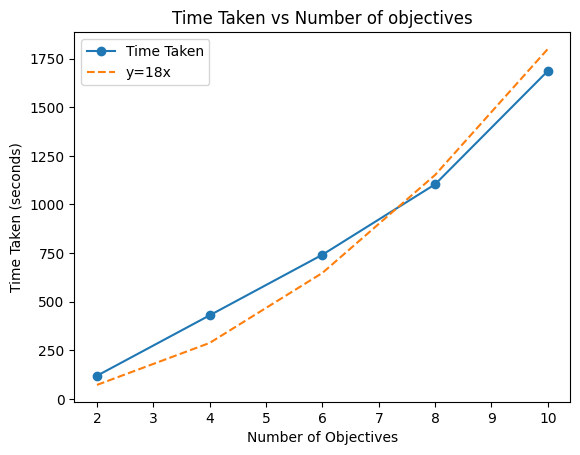

In [132]:
# plot the time curve
# attach y=x^2
import matplotlib.pyplot as plt

plt.plot(range(2,11,2), time_arr, marker='o')
plt.plot(range(2,11,2), [18*x**2 for x in range(2,11,2)], linestyle='--')
plt.xlabel('Number of Objectives')
plt.ylabel('Time Taken (seconds)')
plt.legend(['Time Taken', 'y=18x'])
plt.title('Time Taken vs Number of objectives')
plt.show()

conclusion: time is in $O(m^2)$ with increasing of the number of objectives